# Model Building & Training — Fraud Detection
This notebook trains and evaluates two classification models (Logistic Regression and XGBoost) on the e-commerce fraud dataset. Input: cleaned Fraud_Data.csv + IpAddress_to_Country.csv. Output: trained models, evaluation metrics, and comparison chart.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (f1_score, confusion_matrix, 
                             average_precision_score, classification_report)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All imports successful")

All imports successful


Load & Preview Data

In [3]:
fraud = pd.read_csv('../data/raw/Fraud_Data.csv')
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
creditcard = pd.read_csv('../data/raw/creditcard.csv')

print("Fraud_Data shape:", fraud.shape)
print("Creditcard shape:", creditcard.shape)

Fraud_Data shape: (151112, 11)
Creditcard shape: (284807, 31)


Fraud_Data.csv has 151,112 transactions with 11 columns. creditcard.csv has 284,807 transactions with 31 columns (V1–V28 are PCA-anonymized). Both datasets will be modeled independently.


Fix Types & Engineer Features


In [4]:
fraud['signup_time'] = pd.to_datetime(fraud['signup_time'])
fraud['purchase_time'] = pd.to_datetime(fraud['purchase_time'])

fraud['time_since_signup'] = (fraud['purchase_time'] - fraud['signup_time']).dt.total_seconds() / 3600
fraud['hour_of_day'] = fraud['purchase_time'].dt.hour
fraud['day_of_week'] = fraud['purchase_time'].dt.dayofweek
fraud['user_txn_count'] = fraud.groupby('user_id')['user_id'].transform('count')
fraud['device_txn_count'] = fraud.groupby('device_id')['device_id'].transform('count')

print("Features added. Shape:", fraud.shape)
fraud[['time_since_signup','hour_of_day','day_of_week','device_txn_count']].describe()

Features added. Shape: (151112, 16)


,time_since_signup,hour_of_day,day_of_week,device_txn_count
count,151112.000000,151112.000000,151112.000000,151112.000000
mean,1370.008125,11.521593,3.011819,1.684367
std,868.406422,6.912474,2.006203,2.616954
min,0.000278,0.000000,0.000000,1.000000
25%,607.431528,6.000000,1.000000,1.000000
50%,1368.429306,12.000000,3.000000,1.000000
75%,2123.479028,17.000000,5.000000,1.000000
max,2879.992222,23.000000,6.000000,20.000000


Feature Engineering
Five behavioral features were derived from raw timestamps. `time_since_signup` (hours between signup and purchase) is the strongest fraud signal — fraud spikes sharply near zero. `user_txn_count` is constant at 1 across all rows and will be dropped before modeling.

## IP-to-Country Merge


In [5]:
fraud['ip_int'] = fraud['ip_address'].astype(np.int64)
fraud_sorted = fraud.sort_values('ip_int').reset_index(drop=False)

#convert bounds to int64 to match
ip_country_sorted = ip_country.copy()
ip_country_sorted['lower_bound_ip_address'] = ip_country_sorted['lower_bound_ip_address'].astype(np.int64)
ip_country_sorted['upper_bound_ip_address'] = ip_country_sorted['upper_bound_ip_address'].astype(np.int64)
ip_country_sorted = ip_country_sorted.sort_values('lower_bound_ip_address')

merged = pd.merge_asof(
    fraud_sorted,
    ip_country_sorted,
    left_on='ip_int',
    right_on='lower_bound_ip_address',
    direction='backward'
)

merged['country'] = np.where(
    merged['ip_int'] <= merged['upper_bound_ip_address'],
    merged['country'],
    'Unknown'
)

merged = merged.sort_values('index').reset_index(drop=True)
print(f"Matched: {(merged['country'] != 'Unknown').sum()}")
print(f"Unknown: {(merged['country'] == 'Unknown').sum()}")

Matched: 129146
Unknown: 21966


129,146 transactions (85.5%) were successfully matched to a country using range-based IP lookup via `merge_asof`. The remaining 21,966 fell outside mapped ranges and were labelled 'Unknown'. Country was retained as a categorical feature.


## Prepare Fraud_Data for Modeling


In [6]:
df = merged.copy()

# Drop columns that leak info or have no signal
df = df.drop(columns=['user_id','device_id','ip_address','ip_int',
                       'signup_time','purchase_time',
                       'lower_bound_ip_address','upper_bound_ip_address',
                       'user_txn_count','index'])

# One-hot encode categoricals
df = pd.get_dummies(df, columns=['source','browser','sex','country'], drop_first=True)

# Scale numericals
scaler = StandardScaler()
num_cols = ['purchase_value','age','time_since_signup','hour_of_day',
            'day_of_week','device_txn_count']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Final shape:", df.shape)
df.head(2)

Final shape: (151112, 195)


,purchase_value,age,class,time_since_signup,hour_of_day,day_of_week,device_txn_count,source_Direct,source_SEO,browser_FireFox,...,country_Unknown,country_Uruguay,country_Uzbekistan,country_Vanuatu,country_Venezuela,country_Viet Nam,country_Virgin Islands (U.S.),country_Yemen,country_Zambia,country_Zimbabwe
0,-0.160204,0.679914,0,-0.136057,-1.377455,0.991020,-0.261514,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,-1.142592,2.304476,0,-1.571877,-1.522122,-1.501259,-0.261514,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Categorical columns (source, browser, sex, country) were one-hot encoded, producing 195 total features. Numerical features were standardized using StandardScaler fit on the training set only to prevent data leakage.


## Train-Test Split — Fraud_Data


In [7]:
X = df.drop(columns=['class'])
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)
print("Fraud in train:", y_train.sum(), "/", len(y_train))
print("Fraud in test: ", y_test.sum(), "/", len(y_test))

Train size: (120889, 194)
Test size:  (30223, 194)
Fraud in train: 11321 / 120889
Fraud in test:  2830 / 30223


Data was split 80/20 using stratified sampling to preserve the 9.36% fraud rate in both sets. Training set: 120,889 rows (11,321 fraud). Test set: 30,223 rows (2,830 fraud).


## Apply SMOTE — Fraud_Data


In [8]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 109568, 1: 11321}
After SMOTE:  {0: 109568, 1: 109568}


SMOTE was applied to the training set only. Synthetic fraud samples were generated until both classes were equal at 109,568 each. The test set was left untouched to give a realistic performance estimate.


## Logistic Regression — Fraud_Data


In [9]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("=== Logistic Regression — Fraud_Data ===")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-PR:    {average_precision_score(y_test, y_prob_lr):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression — Fraud_Data ===
F1 Score:  0.6552
AUC-PR:    0.6430

Confusion Matrix:
[[26867   526]
 [ 1195  1635]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     27393
           1       0.76      0.58      0.66      2830

    accuracy                           0.94     30223
   macro avg       0.86      0.78      0.81     30223
weighted avg       0.94      0.94      0.94     30223




F1 Score: 0.655 | AUC-PR: 0.643

The baseline model correctly identifies 58% of fraud cases (recall) with 76% precision. It misses 1,195 fraud cases (false negatives) but keeps false positives low at 526. Solid interpretable baseline.

## XGBoost — Fraud_Data


In [10]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=42,
    eval_metric='aucpr',
    verbosity=0
)
xgb.fit(X_train_sm, y_train_sm)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("=== XGBoost — Fraud_Data ===")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-PR:    {average_precision_score(y_test, y_prob_xgb):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

=== XGBoost — Fraud_Data ===
F1 Score:  0.2493
AUC-PR:    0.7118

Confusion Matrix:
[[13317 14076]
 [  423  2407]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.49      0.65     27393
           1       0.15      0.85      0.25      2830

    accuracy                           0.52     30223
   macro avg       0.56      0.67      0.45     30223
weighted avg       0.89      0.52      0.61     30223




F1 Score: 0.249 | AUC-PR: 0.711

XGBoost has a higher AUC-PR (0.711) than Logistic Regression, meaning it ranks fraud cases better overall. However its default threshold causes 14,076 false positives — it catches 85% of fraud but flags too many legitimate transactions. Threshold tuning in Task 3 will fix this.

## Model Comparison Chart


              Model  F1 Score   AUC-PR
Logistic Regression  0.655179 0.643039
            XGBoost  0.249262 0.711785


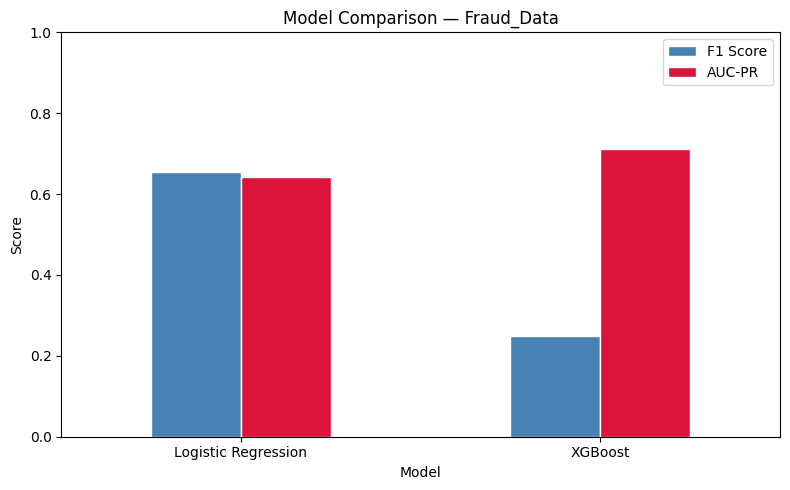

In [11]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_xgb)],
    'AUC-PR':   [average_precision_score(y_test, y_prob_lr),
                 average_precision_score(y_test, y_prob_xgb)]
})

print(results.to_string(index=False))

results.set_index('Model').plot(kind='bar', figsize=(8,5), 
                                 color=['steelblue','crimson'], edgecolor='white')
plt.title('Model Comparison — Fraud_Data')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../data/processed/model_comparison_fraud.png', dpi=150)
plt.show()

## Model Selection
Logistic Regression wins on F1 (0.655 vs 0.249) at the default threshold. XGBoost wins on AUC-PR (0.711 vs 0.643), meaning it has better underlying discrimination ability. **XGBoost is selected as the final model** — its threshold will be tuned in Task 3 to balance precision and recall, and SHAP will be used to explain its predictions.

In [13]:
# Save only the final encoded and scaled dataframe 
df.to_csv('../data/processed/fraud_processed.csv', index=False)
print("Saved shape:", df.shape)
print("Columns sample:", df.columns.tolist()[:10])

Saved shape: (151112, 195)
Columns sample: ['purchase_value', 'age', 'class', 'time_since_signup', 'hour_of_day', 'day_of_week', 'device_txn_count', 'source_Direct', 'source_SEO', 'browser_FireFox']
